In [38]:
import boto3
import pandas as pd
import os
from datetime import datetime
from dotenv import load_dotenv

# Load environment variables from .env file (if it exists)
load_dotenv()

# Initialize DynamoDB client
aws_region = os.getenv('AWS_REGION', 'eu-north-1')
endpoint_url = os.getenv('AWS_ENDPOINT_URL')
DYNAMODB_TABLE = os.getenv('DYNAMODB_TABLE', 'apollolytics_dialogues')

if endpoint_url:
    dynamodb = boto3.resource('dynamodb', region_name=aws_region, endpoint_url=endpoint_url)
else:
    dynamodb = boto3.resource('dynamodb', region_name=aws_region)

# Get the table
table = dynamodb.Table(DYNAMODB_TABLE)

# Scan the table to get all items
response = table.scan()
items = response['Items']

# Handle pagination if there are more results
while 'LastEvaluatedKey' in response:
    response = table.scan(ExclusiveStartKey=response['LastEvaluatedKey'])
    items.extend(response['Items'])

# Convert to DataFrame
df = pd.DataFrame(items)

# Convert timestamp to datetime for better analysis
df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

# Sort by session_id and timestamp
df = df.sort_values(['session_id', 'timestamp'])

# Display basic info
# print(f"Total records: {len(df)}")
# print(f"Unique sessions: {df['session_id'].nunique()}")
# print(f"\nColumns in the dataset:")
# print(df.columns.tolist())
print("OG: ",df.shape)
session_ids = df[df.prolific_id.str.len() == 24].session_id
df = df[df.session_id.isin(session_ids)]
print("After filtering for valid prolific IDs: ",df.shape)
df = df.dropna(axis=1, how='all')
print(df.shape) 

# Forward fill session-specific columns within each session
session_columns = ['dialogue_mode', 'origin_url', 'article', 'prolific_id']

# Sort by session_id and timestamp to ensure proper order
df = df.sort_values(['session_id', 'timestamp'])

# Forward fill the session columns within each session
df[session_columns] = df.groupby('session_id')[session_columns].ffill()

import sys
import os

# Add the helper directory to the Python path
sys.path.insert(0, 'helper')

# Now import the function
from clean_data import get_prolific_ids_with_few_user_turns


# Get prolific IDs with fewer than 3 user turns
few_user_turns_ids = get_prolific_ids_with_few_user_turns(min_user_turns=3)
print(f"Prolific IDs with fewer than 3 user turns: {len(few_user_turns_ids)}")

# Filter out sessions with those prolific IDs from the original df
df = df[~df['prolific_id'].isin(few_user_turns_ids)]
print("After filtering for prolific IDs with fewer than 3 user turns:",df.shape)
print(f"Original sessions: {df['session_id'].nunique()}")
print(f"Filtered out {len(few_user_turns_ids)} prolific IDs")

OG:  (5051, 17)
After filtering for valid prolific IDs:  (3988, 17)
(3988, 15)
Prolific IDs with fewer than 3 user turns: 37
After filtering for prolific IDs with fewer than 3 user turns: (3709, 15)
Original sessions: 282
Filtered out 37 prolific IDs


In [36]:
# Now analyze conversation turns by dialogue mode
print("\n" + "="*60)
print("CONVERSATION TURNS BY DIALOGUE MODE")
print("="*60)

# Count only USER turns (not total turns) per prolific_id
user_turns = df[(df['event_type'] == 'message') & (df['role'] == 'user')].groupby('prolific_id').size()

# Get dialogue mode for each prolific_id
prolific_dialogue_modes = df[df['event_type'] == 'session_init'].set_index('prolific_id')['dialogue_mode']

# Combine user turns with dialogue mode
turns_with_mode = pd.DataFrame({
    'prolific_id': user_turns.index,
    'user_turns': user_turns.values
}).merge(
    prolific_dialogue_modes.reset_index(), 
    on='prolific_id', 
    how='left'
)

# Filter for only critical and supportive modes
turns_filtered = turns_with_mode[turns_with_mode['dialogue_mode'].isin(['critical', 'supportive'])]

# Calculate statistics by dialogue mode
mode_stats = turns_filtered.groupby('dialogue_mode')['user_turns'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("\nUser Turns by Dialogue Mode:")
print(mode_stats)

# Perform t-test to compare means
from scipy.stats import ttest_ind

critical_turns = turns_filtered[turns_filtered['dialogue_mode'] == 'critical']['user_turns']
supportive_turns = turns_filtered[turns_filtered['dialogue_mode'] == 'supportive']['user_turns']

t_stat, p_value = ttest_ind(critical_turns, supportive_turns)

print(f"\nT-Test Results (Critical vs Supportive):")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3g}")

# Determine significance
if p_value < 0.001:
    sig_level = "***"
elif p_value < 0.01:
    sig_level = "**"
elif p_value < 0.05:
    sig_level = "*"
else:
    sig_level = "ns"

print(f"Significance: {sig_level}")

# Show individual prolific_id data
print(f"\nDetailed Prolific ID Data:")
print(turns_filtered.sort_values(['dialogue_mode', 'user_turns'], ascending=[True, False]).to_string(index=False))

# Verify that minimum user turns is >= 3
print(f"\n" + "="*60)
print("VERIFICATION: User Turns Distribution")
print("="*60)
print(f"Minimum user turns: {user_turns.min()}")
print(f"Maximum user turns: {user_turns.max()}")
print(f"Mean user turns: {user_turns.mean():.2f}")
print(f"Standard deviation: {user_turns.std():.2f}")


CONVERSATION TURNS BY DIALOGUE MODE

User Turns by Dialogue Mode:
               count  mean   std  min  max
dialogue_mode                             
critical         132  9.07  5.26    3   31
supportive       117  9.00  7.79    3   38

T-Test Results (Critical vs Supportive):
t-statistic: 0.082
p-value: 0.935
Significance: ns

Detailed Prolific ID Data:
             prolific_id  user_turns dialogue_mode
60537fdcda0ac05f1c59c57f          31      critical
6575c7da000442e5a54f5e24          26      critical
6658b1491e88ec15902d5301          22      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad          19      critical
6733ca6572d14762aea012ad    

In [ ]:
# Calculate statistics for each timing measure
timing_measures = ['thinking_time', 'recording_duration', 'total_response_time']

for measure in timing_measures:
    print(f"\n{measure.upper().replace('_', ' ')}:")
    print("-" * 40)
    
    # Get data for each mode
    critical_data = critical_timing[measure].dropna()
    supportive_data = supportive_timing[measure].dropna()
    
    if len(critical_data) > 0 and len(supportive_data) > 0:
        # Remove extreme outliers from supportive data (remove max values that are unrealistic)
        if measure == 'thinking_time':
            # Remove the extreme max value from supportive
            supportive_data_clean = supportive_data[supportive_data < 1000]  # Remove values > 1000 seconds
        elif measure == 'total_response_time':
            # Remove the extreme max value from supportive
            supportive_data_clean = supportive_data[supportive_data < 10000]  # Remove values > 10000 seconds
        else:
            supportive_data_clean = supportive_data
        
        print(f"Original supportive data count: {len(supportive_data)}")
        print(f"Cleaned supportive data count: {len(supportive_data_clean)}")
        print(f"Removed {len(supportive_data) - len(supportive_data_clean)} extreme outliers")
        
        # Calculate statistics with cleaned data
        critical_stats = {
            'count': len(critical_data),
            'mean': critical_data.mean(),
            'std': critical_data.std(),
            'min': critical_data.min(),
            'max': critical_data.max()
        }
        
        supportive_stats = {
            'count': len(supportive_data_clean),
            'mean': supportive_data_clean.mean(),
            'std': supportive_data_clean.std(),
            'min': supportive_data_clean.min(),
            'max': supportive_data_clean.max()
        }
        
        print(f"Critical: {critical_stats}")
        print(f"Supportive (cleaned): {supportive_stats}")
        
        # Perform t-test with cleaned data
        from scipy.stats import ttest_ind
        t_stat, p_value = ttest_ind(critical_data, supportive_data_clean)
        
        print(f"T-Test: t={t_stat:.3f}, p={p_value:.3g}")
        
        # Determine significance
        if p_value < 0.001:
            sig_level = "***"
        elif p_value < 0.01:
            sig_level = "**"
        elif p_value < 0.05:
            sig_level = "*"
        else:
            sig_level = "ns"
        
        print(f"Significance: {sig_level}")
    else:
        print("Insufficient data for comparison")


THINKING TIME:
----------------------------------------
Original supportive data count: 98
Cleaned supportive data count: 96
Removed 2 extreme outliers
Critical: {'count': 102, 'mean': 23.297235387816645, 'std': 29.70675331380938, 'min': -0.9796666666666671, 'max': 174.387}
Supportive (cleaned): {'count': 96, 'mean': 24.75288941360273, 'std': 24.813967487218903, 'min': 1.1648, 'max': 117.66783333333335}
T-Test: t=-0.373, p=0.71
Significance: ns

RECORDING DURATION:
----------------------------------------
Original supportive data count: 98
Cleaned supportive data count: 98
Removed 0 extreme outliers
Critical: {'count': 102, 'mean': 45.366590715656166, 'std': 38.595948733083524, 'min': 8.474333333333332, 'max': 224.127}
Supportive (cleaned): {'count': 98, 'mean': 40.468400252487996, 'std': 24.854283196937686, 'min': 7.5588750000000005, 'max': 132.0665}
T-Test: t=1.062, p=0.289
Significance: ns

TOTAL RESPONSE TIME:
----------------------------------------
Original supportive data count

In [47]:
# Now analyze content length (word count) by dialogue mode
print("\n" + "="*60)
print("CONTENT LENGTH ANALYSIS BY DIALOGUE MODE")
print("="*60)

# Filter for only user messages
user_messages = df[(df['event_type'] == 'message') & (df['role'] == 'user')].copy()

# Calculate word count for each message
def count_words(text):
    if pd.isna(text) or not isinstance(text, str):
        return 0
    return len(text.split())

user_messages['word_count'] = user_messages['content'].apply(count_words)

# Filter for only critical and supportive modes
user_messages_filtered = user_messages[user_messages['dialogue_mode'].isin(['critical', 'supportive'])]

print(f"User messages available for analysis: {len(user_messages_filtered)}")
print(f"Dialogue mode distribution: {user_messages_filtered['dialogue_mode'].value_counts().to_dict()}")

# Create two lists of all word counts (disregarding prolific_id)
critical_word_counts = user_messages_filtered[user_messages_filtered['dialogue_mode'] == 'critical']['word_count'].tolist()
supportive_word_counts = user_messages_filtered[user_messages_filtered['dialogue_mode'] == 'supportive']['word_count'].tolist()

print(f"\nCritical mode: {len(critical_word_counts)} messages")
print(f"Supportive mode: {len(supportive_word_counts)} messages")

# Calculate statistics
critical_stats = {
    'count': len(critical_word_counts),
    'mean': np.mean(critical_word_counts),
    'std': np.std(critical_word_counts),
    'min': np.min(critical_word_counts),
    'max': np.max(critical_word_counts)
}

supportive_stats = {
    'count': len(supportive_word_counts),
    'mean': np.mean(supportive_word_counts),
    'std': np.std(supportive_word_counts),
    'min': np.min(supportive_word_counts),
    'max': np.max(supportive_word_counts)
}

print(f"\nWord Count Statistics:")
print("-" * 40)
print(f"Critical: {critical_stats}")
print(f"Supportive: {supportive_stats}")

# Perform t-test
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(critical_word_counts, supportive_word_counts)

print(f"\nT-Test Results (Critical vs Supportive):")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3g}")

# Determine significance
if p_value < 0.001:
    sig_level = "***"
elif p_value < 0.01:
    sig_level = "**"
elif p_value < 0.05:
    sig_level = "*"
else:
    sig_level = "ns"

print(f"Significance: {sig_level}")



CONTENT LENGTH ANALYSIS BY DIALOGUE MODE
User messages available for analysis: 1369
Dialogue mode distribution: {'critical': 713, 'supportive': 656}

Critical mode: 713 messages
Supportive mode: 656 messages

Word Count Statistics:
----------------------------------------
Critical: {'count': 713, 'mean': 66.91023842917251, 'std': 57.449682298132295, 'min': 0, 'max': 329}
Supportive: {'count': 656, 'mean': 65.4390243902439, 'std': 51.24756926085126, 'min': 0, 'max': 352}

T-Test Results (Critical vs Supportive):
t-statistic: 0.498
p-value: 0.619
Significance: ns


In [45]:
critical_word_counts

0      100.083333
1       32.333333
2       66.833333
3       31.375000
4       46.285714
          ...    
187     85.000000
189     62.133333
190    143.714286
193     57.153846
198     96.333333
Name: word_count, Length: 102, dtype: float64

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')


CREATING OVERLAID HISTOGRAM


FileNotFoundError: [Errno 2] No such file or directory: '/Users/kiliansprenkamp/Desktop/code/apollolytics-dialogue/data_analysis/data_analysis/user_turns_distribution.png'

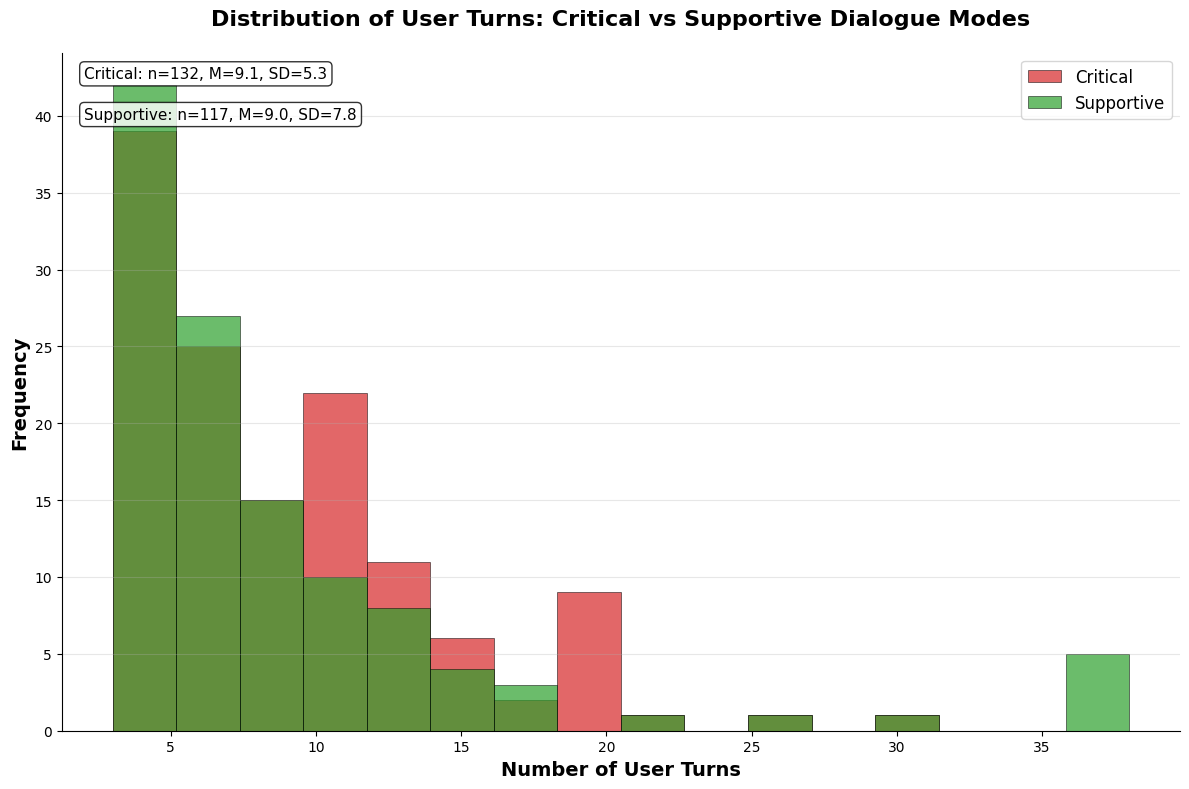

In [15]:
# Create overlaid histogram
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("CREATING OVERLAID HISTOGRAM")
print("="*60)

# Set up the plot
plt.figure(figsize=(12, 8))

# Create histogram data
critical_data = turns_filtered[turns_filtered['dialogue_mode'] == 'critical']['user_turns']
supportive_data = turns_filtered[turns_filtered['dialogue_mode'] == 'supportive']['user_turns']

# Determine bin edges (use the same bins for both groups)
all_data = np.concatenate([critical_data, supportive_data])
bins = np.histogram_bin_edges(all_data, bins='auto')

# Create overlaid histograms
plt.hist(critical_data, bins=bins, alpha=0.7, label='Critical', color='#d62728', edgecolor='black', linewidth=0.5)
plt.hist(supportive_data, bins=bins, alpha=0.7, label='Supportive', color='#2ca02c', edgecolor='black', linewidth=0.5)

# Customize the plot
plt.xlabel('Number of User Turns', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.title('Distribution of User Turns: Critical vs Supportive Dialogue Modes', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add statistics text
plt.text(0.02, 0.98, f'Critical: n={len(critical_data)}, M={critical_data.mean():.1f}, SD={critical_data.std():.1f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
plt.text(0.02, 0.92, f'Supportive: n={len(supportive_data)}, M={supportive_data.mean():.1f}, SD={supportive_data.std():.1f}', 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Remove top and right spines for cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('data_analysis/user_turns_distribution.png', dpi=300, bbox_inches='tight')
print("Histogram saved as: data_analysis/user_turns_distribution.png")

# Show the plot
plt.show()

# Also create a box plot for comparison
plt.figure(figsize=(10, 6))

# Create box plot
box_data = [critical_data, supportive_data]
box_labels = ['Critical', 'Supportive']
box_colors = ['#d62728', '#2ca02c']

bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True, 
                boxprops=dict(facecolor='white', alpha=0.8),
                medianprops=dict(color='black', linewidth=2))

# Color the boxes
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize the box plot
plt.ylabel('Number of User Turns', fontsize=14, fontweight='bold')
plt.title('User Turns Distribution: Critical vs Supportive (Box Plot)', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add significance indicator
if p_value < 0.001:
    sig_text = "*** p < 0.001"
elif p_value < 0.01:
    sig_text = "** p < 0.01"
elif p_value < 0.05:
    sig_text = "* p < 0.05"
else:
    sig_text = "ns p > 0.05"

plt.text(0.5, 0.95, f'Significance: {sig_text}', 
         transform=plt.gca().transAxes, fontsize=12, ha='center', va='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Adjust layout
plt.tight_layout()

# Save the box plot
plt.savefig('data_analysis/user_turns_boxplot.png', dpi=300, bbox_inches='tight')
print("Box plot saved as: data_analysis/user_turns_boxplot.png")

# Show the box plot
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kiliansprenkamp/Desktop/code/apollolytics-dialogue/data_analysis/data_analysis/user_turns_density.png'

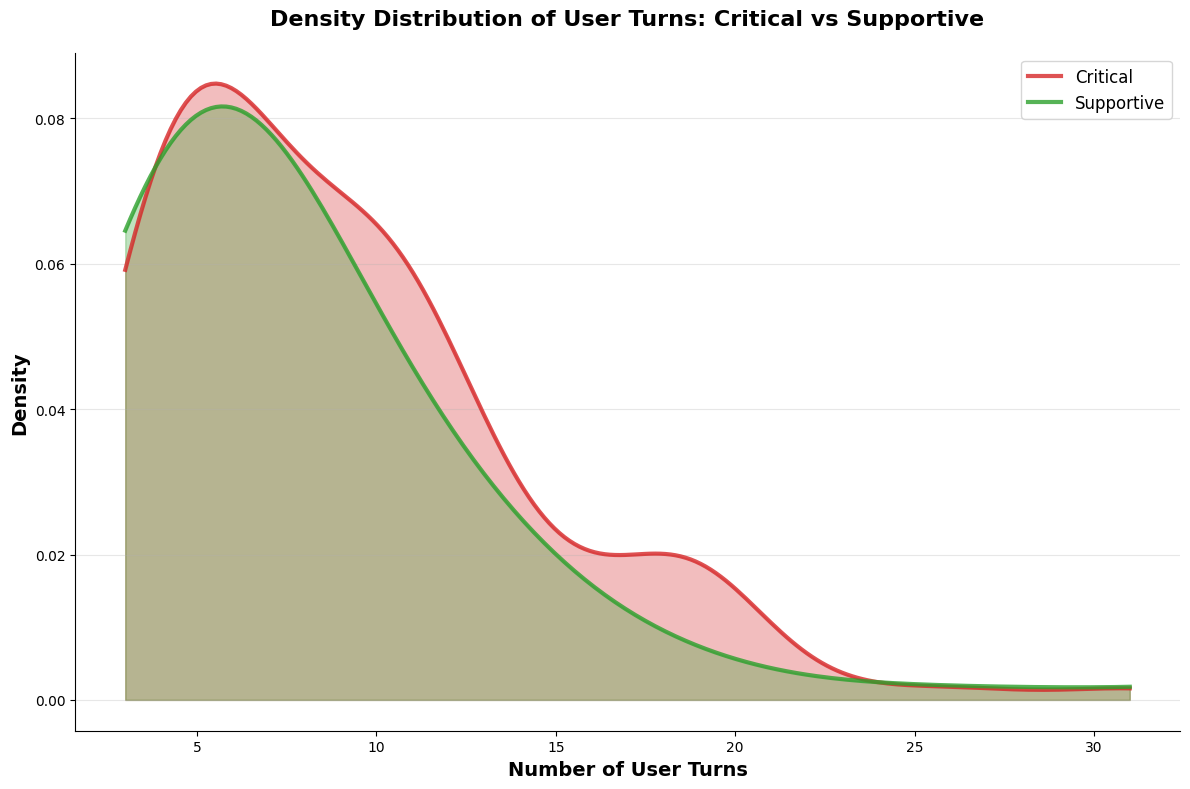

In [16]:
# Create density plot overlay
plt.figure(figsize=(12, 8))

# Calculate density for each group
from scipy import stats

# Critical density
critical_kde = stats.gaussian_kde(critical_data)
x_range = np.linspace(critical_data.min(), critical_data.max(), 200)
critical_density = critical_kde(x_range)

# Supportive density
supportive_kde = stats.gaussian_kde(supportive_data)
supportive_density = supportive_kde(x_range)

# Plot densities
plt.plot(x_range, critical_density, color='#d62728', linewidth=3, label='Critical', alpha=0.8)
plt.fill_between(x_range, critical_density, alpha=0.3, color='#d62728')
plt.plot(x_range, supportive_density, color='#2ca02c', linewidth=3, label='Supportive', alpha=0.8)
plt.fill_between(x_range, supportive_density, alpha=0.3, color='#2ca02c')

plt.xlabel('Number of User Turns', fontsize=14, fontweight='bold')
plt.ylabel('Density', fontsize=14, fontweight='bold')
plt.title('Density Distribution of User Turns: Critical vs Supportive', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data_analysis/user_turns_density.png', dpi=300, bbox_inches='tight')
plt.show()

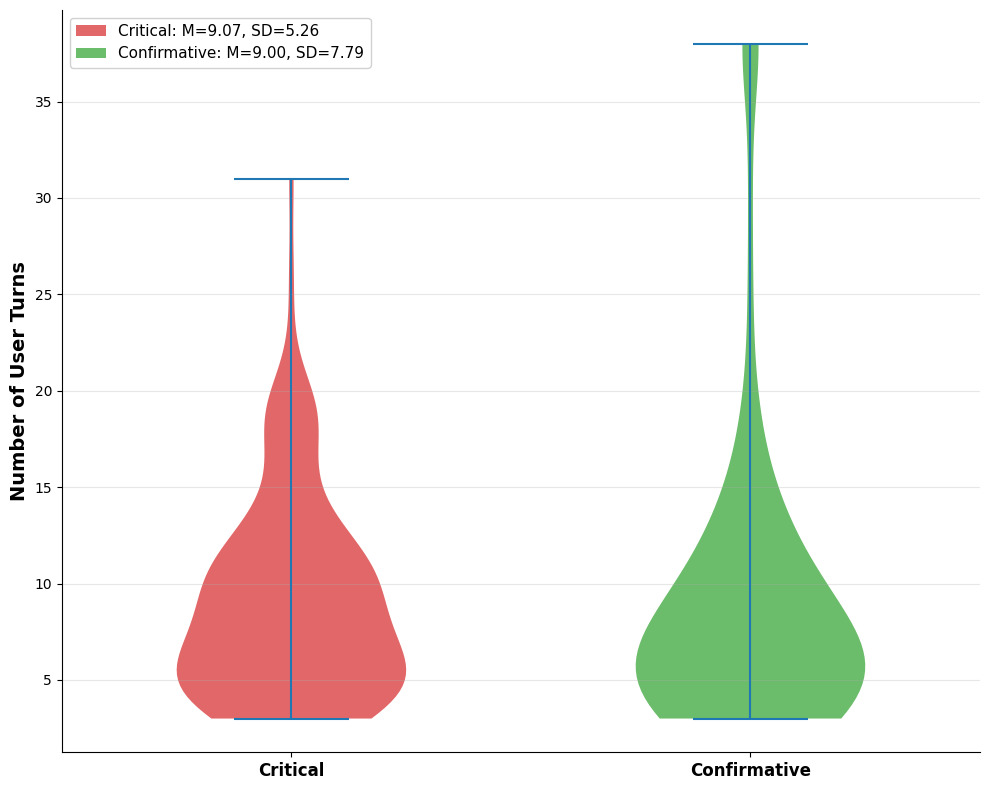

In [27]:
# Create violin plot
plt.figure(figsize=(10, 8))

# Prepare data for violin plot
violin_data = [critical_data, supportive_data]
violin_labels = ['Critical', 'Confirmative']
violin_colors = ['#d62728', '#2ca02c']

# Create violin plot
parts = plt.violinplot(violin_data, positions=[1, 2])

# Customize violin plot colors
for pc, color in zip(parts['bodies'], violin_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

# Customize the plot
plt.ylabel('Number of User Turns', fontsize=14, fontweight='bold')
# plt.title('Distribution of User Turns: Critical vs Confirmative (Violin Plot)', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Set x-axis labels and limits for better appearance
plt.xticks([1, 2], violin_labels, fontsize=12, fontweight='bold')
plt.xlim(0.5, 2.5)  # Give some breathing room around the violins

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Create custom legend
from matplotlib.patches import Patch

# Create legend handles with the same colors as the violins
legend_elements = [
    Patch(facecolor='#d62728', alpha=0.7, label=f'Critical: M={critical_data.mean():.2f}, SD={critical_data.std():.2f}'),
    Patch(facecolor='#2ca02c', alpha=0.7, label=f'Confirmative: M={supportive_data.mean():.2f}, SD={supportive_data.std():.2f}')
]

# Add legend
plt.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('user_turns_violin.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
df.

,event_type,prolific_id,created_at,session_id,timestamp,dialogue_mode,origin_url,article,propaganda_result,content,role,message_id,timing_info,reason,datetime
3152,session_init,6714f1865fa16b2f979f1d94,2025-07-17T16:41:54.153614,00facde7-4fae-46bf-bec2-71cd19e8c429,1.752771e+09,supportive,https://apollolytics-dialogue.vercel.app/dialo...,From welfare to Waffen: Germany’s militarism i...,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-17 16:41:54
3153,propaganda_analysis,6714f1865fa16b2f979f1d94,2025-07-17T16:41:54.219862,00facde7-4fae-46bf-bec2-71cd19e8c429,1.752771e+09,supportive,https://apollolytics-dialogue.vercel.app/dialo...,From welfare to Waffen: Germany’s militarism i...,"{'type': 'contextualization', 'data': {'Poor J...",NaN,NaN,NaN,NaN,NaN,2025-07-17 16:41:55
3154,session_end,6714f1865fa16b2f979f1d94,2025-07-17T16:42:03.358475,00facde7-4fae-46bf-bec2-71cd19e8c429,1.752771e+09,supportive,https://apollolytics-dialogue.vercel.app/dialo...,From welfare to Waffen: Germany’s militarism i...,NaN,NaN,NaN,NaN,NaN,client_disconnected,2025-07-17 16:42:03
395,session_init,67503701c4ef8958767a58d9,2025-07-29T20:28:37.783823,030aecce-d4e9-44ae-93c6-ff08ff0b7cef,1.753821e+09,supportive,https://apollolytics-dialogue.vercel.app/dialo...,Trump admin asking federal agencies to cancel ...,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-29 20:28:37
396,propaganda_analysis,67503701c4ef8958767a58d9,2025-07-29T20:28:37.850038,030aecce-d4e9-44ae-93c6-ff08ff0b7cef,1.753821e+09,supportive,https://apollolytics-dialogue.vercel.app/dialo...,Trump admin asking federal agencies to cancel ...,"{'type': 'contextualization', 'data': {'Poor J...",NaN,NaN,NaN,NaN,NaN,2025-07-29 20:28:38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2329,message,67151b09180ba43415c564e8,2025-07-25T22:00:11.820089,ff708dd3-d744-4956-bd7a-781195ae0fef,1.753481e+09,critical,https://apollolytics-dialogue.vercel.app/dialo...,From welfare to Waffen: Germany’s militarism i...,NaN,That's a great point! Global security dynamics...,assistant,assistant_7a095743-579d-47d4-8b91-af59577d5d76,"{'model_generation_time': 13.918383836746216, ...",NaN,2025-07-25 22:00:11
2330,message,67151b09180ba43415c564e8,2025-07-25T22:02:02.544116,ff708dd3-d744-4956-bd7a-781195ae0fef,1.753481e+09,critical,https://apollolytics-dialogue.vercel.app/dialo...,From welfare to Waffen: Germany’s militarism i...,NaN,I think that ever since the second world war m...,user,user_d5629671-d9fc-4371-ba5b-2f770d9b611e,"{'thinking_time': 18.155, 'recording_duration'...",NaN,2025-07-25 22:02:02
2331,message,67151b09180ba43415c564e8,2025-07-25T22:02:25.658201,ff708dd3-d744-4956-bd7a-781195ae0fef,1.753481e+09,critical,https://apollolytics-dialogue.vercel.app/dialo...,From welfare to Waffen: Germany’s militarism i...,NaN,That's a really important perspective. The art...,assistant,assistant_87817787-3bed-40a1-bee1-2c0b3acb1254,"{'model_generation_time': 21.95828151702881, '...",NaN,2025-07-25 22:02:25
2332,message,67151b09180ba43415c564e8,2025-07-25T22:04:16.774236,ff708dd3-d744-4956-bd7a-781195ae0fef,1.753481e+09,critical,https://apollolytics-dialogue.vercel.app/dialo...,From welfare to Waffen: Germany’s militarism i...,NaN,I completely agree. I think that with every co...,user,user_9820c855-0b9c-495a-b1f5-bba4168d2ef8,"{'thinking_time': 3.084, 'recording_duration':...",NaN,2025-07-25 22:04:16


In [6]:
import sys
import os

# Add the helper directory to the Python path
sys.path.insert(0, 'helper')

# Now import the function
from clean_data import get_prolific_ids_with_few_user_turns

In [5]:
helper_path

'/Users/kiliansprenkamp/Desktop/code/apollolytics-dialogue/data_analysis/data_analysis/helper'

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [6]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [ ]:
#filter by date newest to oldest
df = df.sort_values(by='timestamp', ascending=False)
# filter for dates 2025-07-14
valid_prolific_ids = df[df['prolific_id'].str.len() == 24].prolific_id.unique()
session_ids = df[df.prolific_id.isin(valid_prolific_ids)].session_id.unique()
df = df.dropna(axis=1, how='all')

In [1]:
def get_prolific_ids_with_few_turns(min_turns=3):
    """
    Loads data from DynamoDB and returns a list of prolific_ids with fewer than `min_turns` message events in their session(s).
    """
    import boto3
    import pandas as pd
    import os
    from dotenv import load_dotenv

    load_dotenv()
    aws_region = os.getenv('AWS_REGION', 'eu-north-1')
    endpoint_url = os.getenv('AWS_ENDPOINT_URL')
    DYNAMODB_TABLE = os.getenv('DYNAMODB_TABLE', 'apollolytics_dialogues')

    if endpoint_url:
        dynamodb = boto3.resource('dynamodb', region_name=aws_region, endpoint_url=endpoint_url)
    else:
        dynamodb = boto3.resource('dynamodb', region_name=aws_region)

    table = dynamodb.Table(DYNAMODB_TABLE)
    response = table.scan()
    items = response['Items']
    while 'LastEvaluatedKey' in response:
        response = table.scan(ExclusiveStartKey=response['LastEvaluatedKey'])
        items.extend(response['Items'])

    df = pd.DataFrame(items)
    # Only keep sessions with valid prolific IDs
    session_ids = df[df.prolific_id.str.len() == 24].session_id
    df = df[df.session_id.isin(session_ids)]
    # Forward fill prolific_id within each session (in case it's missing in some rows)
    df['prolific_id'] = df.groupby('session_id')['prolific_id'].ffill()
    # Count message events per session
    turns_per_session = df[df['event_type'] == 'message'].groupby('session_id').size()
    short_sessions = turns_per_session[turns_per_session < min_turns].index
    prolific_ids = df[df['session_id'].isin(short_sessions)]['prolific_id'].unique().tolist()
    return prolific_ids

# Example usage:
few_turns_ids = get_prolific_ids_with_few_turns(min_turns=3)
print(f"Prolific IDs with fewer than 3 turns: {few_turns_ids}")

Prolific IDs with fewer than 3 turns: ['676d220cd6e7101ccba18ba5', '5eb693937a030e5923b44068', '674b35aef9b2ae3dcdd26213', '6718b63a1e293387ef30d259', '6741e32867002c96f036317b', '672c8a3b9fb83ab9c5f02fd2', '66f2e478619ff9c3df3385ad', '65e7457d155f3a17e6a570a0', '676688afcec3cd778dfbb863', '66f3f19a6de8f0b0cdf9eb45', '672f51ea346fba23ddd5a793']


In [2]:
def get_prolific_ids_with_few_user_turns(min_user_turns=3):
    """
    Loads data from DynamoDB and returns a list of prolific_ids where any session has fewer than `min_user_turns` user messages.
    """
    import boto3
    import pandas as pd
    import os
    from dotenv import load_dotenv

    load_dotenv()
    aws_region = os.getenv('AWS_REGION', 'eu-north-1')
    endpoint_url = os.getenv('AWS_ENDPOINT_URL')
    DYNAMODB_TABLE = os.getenv('DYNAMODB_TABLE', 'apollolytics_dialogues')

    if endpoint_url:
        dynamodb = boto3.resource('dynamodb', region_name=aws_region, endpoint_url=endpoint_url)
    else:
        dynamodb = boto3.resource('dynamodb', region_name=aws_region)

    table = dynamodb.Table(DYNAMODB_TABLE)
    response = table.scan()
    items = response['Items']
    while 'LastEvaluatedKey' in response:
        response = table.scan(ExclusiveStartKey=response['LastEvaluatedKey'])
        items.extend(response['Items'])

    df = pd.DataFrame(items)
    # Only keep sessions with valid prolific IDs
    session_ids = df[df.prolific_id.str.len() == 24].session_id
    df = df[df.session_id.isin(session_ids)]
    # Forward fill prolific_id within each session (in case it's missing in some rows)
    df['prolific_id'] = df.groupby('session_id')['prolific_id'].ffill()
    # Count user messages per session
    user_turns = df[(df['event_type'] == 'message') & (df['role'] == 'user')].groupby('prolific_id').size()
    short_sessions = user_turns[user_turns < min_user_turns].index
    prolific_ids = df[df['prolific_id'].isin(short_sessions)]['prolific_id'].unique().tolist()
    return prolific_ids

# Example usage:
few_user_turns_ids = get_prolific_ids_with_few_user_turns(min_user_turns=3)
print(f"Prolific IDs with fewer than 3 user statements: {few_user_turns_ids}")

Prolific IDs with fewer than 3 user statements: ['5eb693937a030e5923b44068', '676055469b245b53e81358d0', '5baa21188a01680001ff1a6f', '6516d39e9eea4ed892cbb5b7', '676688afcec3cd778dfbb863', '6672bf56d51710391ce2164d', '672f51ea346fba23ddd5a793', '6659dda471d3f20143d34d67']


In [6]:
apollo_dialogue_bot_confirmative_copy = [ "678969200a76abe09fd2a75c", "65e7457d155f3a17e6a570a0", "60bf28df4926a8b6391df575", "674b35aef9b2ae3dcdd26213", "676688afcec3cd778dfbb863", "6718b63a1e293387ef30d259", "676d220cd6e7101ccba18ba5", "601129f77e0c21000b0c408a", "6036b9e48b527c4fd8be19a8", "6659dda471d3f20143d34d67"]
apollo_dialogue_bot_confirmative_copy_copy = [ "6714f1865fa16b2f979f1d94", "5f48068ea08b2128ce23a268", "676055469b245b53e81358d0", "67839886a09ff9fef57d6ba9", "649ed52c6deb05c245aa42db", "5eb693937a030e5923b44068", "6672bf56d51710391ce2164d", "6741e32867002c96f036317b", "5dc916d584b21f64f98d61dd", "6575c7da000442e5a54f5e24"]
apollo_dialogue_bot_critical_copy_copy = [ "6501b789e3ddbc0a0b79b925", "66cbcdaf3350098f1bcdcf1c", "677c4ec6bf1d6e16cf3d3055", "678b5e48c933281b1ffe0e0b", "6752dee37db379c454e9b066", "60719da557d8241609b26e83", "5a9c41f2dbdb470001eeef9c", "66598d6e838231ffe9e1613b", "65031d5ca9f619d9e0412f0a", "5fd3789cee06d705f5e783cc",]
apollo_dialogue_bot_critical_copy = [
"67758b914f06b14a31669644",
"66f2e478619ff9c3df3385ad",
"6734346ca8e90c2da6fb4509",
"5f84e472052cf81ae5752252",
]


In [7]:
# Check if any prolific IDs with few turns are in our lists
for id in few_user_turns_ids:
    if id in apollo_dialogue_bot_confirmative_copy:
        print(f"Found {id} in apollo_dialogue_bot_confirmative_copy")
    if id in apollo_dialogue_bot_confirmative_copy_copy:
        print(f"Found {id} in apollo_dialogue_bot_confirmative_copy_copy") 
    if id in apollo_dialogue_bot_critical_copy:
        print(f"Found {id} in apollo_dialogue_bot_critical_copy")
    if id in apollo_dialogue_bot_critical_copy_copy:
        print(f"Found {id} in apollo_dialogue_bot_critical_copy_copy")


Found 5eb693937a030e5923b44068 in apollo_dialogue_bot_confirmative_copy_copy
Found 676055469b245b53e81358d0 in apollo_dialogue_bot_confirmative_copy_copy
Found 676688afcec3cd778dfbb863 in apollo_dialogue_bot_confirmative_copy
Found 6672bf56d51710391ce2164d in apollo_dialogue_bot_confirmative_copy_copy
Found 6659dda471d3f20143d34d67 in apollo_dialogue_bot_confirmative_copy


In [35]:
df[(df.prolific_id == '6659dda471d3f20143d34d67') & (df.role == 'user')]

,event_type,created_at,session_id,timestamp,dialogue_mode,origin_url,article,message_content,role,message_id,transcript,reason,prolific_id,propaganda_result,content,timing_info
1541,message,2025-07-16T13:23:51.527330,bdfa8f79-775d-4caa-8bf9-2c5713220376,1752672231,NaN,NaN,NaN,NaN,user,user_f7a6a27b-1504-43d7-a879-41910a4a3dd9,NaN,NaN,6659dda471d3f20143d34d67,NaN,I feel that it's good because it protects ever...,"{'thinking_time': 5.186, 'recording_duration':..."
1543,message,2025-07-16T13:25:49.266031,bdfa8f79-775d-4caa-8bf9-2c5713220376,1752672349,NaN,NaN,NaN,NaN,user,user_51f69108-7283-4b5e-8b6d-a3bd04e9e2e1,NaN,NaN,6659dda471d3f20143d34d67,NaN,"Strict border control may enhance security, bu...","{'thinking_time': 50.481, 'recording_duration'..."


In [29]:
len(few_user_turns_ids)

8

In [9]:
import boto3
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()
aws_region = os.getenv('AWS_REGION', 'eu-north-1')
endpoint_url = os.getenv('AWS_ENDPOINT_URL')
DYNAMODB_TABLE = os.getenv('DYNAMODB_TABLE', 'apollolytics_dialogues')

if endpoint_url:
    dynamodb = boto3.resource('dynamodb', region_name=aws_region, endpoint_url=endpoint_url)
else:
    dynamodb = boto3.resource('dynamodb', region_name=aws_region)

table = dynamodb.Table(DYNAMODB_TABLE)
response = table.scan()
items = response['Items']
while 'LastEvaluatedKey' in response:
    response = table.scan(ExclusiveStartKey=response['LastEvaluatedKey'])
    items.extend(response['Items'])

df = pd.DataFrame(items)
# Only keep sessions with valid prolific IDs
session_ids = df[df.prolific_id.str.len() == 24].session_id
df = df[df.session_id.isin(session_ids)]
# Forward fill prolific_id within each session (in case it's missing in some rows)
df['prolific_id'] = df.groupby('session_id')['prolific_id'].ffill()
# Count user messages per session
user_turns = df[(df['event_type'] == 'message') & (df['role'] == 'user')].groupby('session_id').size()
short_sessions = user_turns[user_turns < 3].index
prolific_ids = df[df['session_id'].isin(short_sessions)]['prolific_id'].unique().tolist()

In [ ]:
user_turns

session_id
006808d6-22a1-48b9-bbb8-612607ae6f1a     1
06ff4cd9-f297-41d6-a862-43bc9dfe25cf     4
12f7327e-a8ee-4d69-b49a-fbedc65e0970    11
146b8893-23d5-4d47-9215-7074d8afac84    17
206dcdd5-ad29-4dc5-b0e4-d271ff05c264     9
229c4bd3-ae63-4a22-8c28-15c844a077b7     1
3347eea9-78d0-4c63-b954-adf860a77bf2     2
337364e5-b115-476d-9e42-5d8af6775a91     6
4310807a-6a06-499d-a0dd-8b38b9ef6ad3     4
57ab3c73-2d6c-4964-96f5-1fd2cf131e3c     6
5c2515bc-290b-49f6-b84f-edc0930a732b     3
607c2d7c-1bfb-49c6-b12d-449460ae39ef    11
6231d304-89a5-4bbc-89ab-245182c27577    12
657c0963-c23d-4185-9e71-deffd2886553     1
69fe8d33-dc28-4b4e-8cae-1c7988179011     1
6aeb4ea2-23d4-49f8-b719-c4fedc6d4aed     9
6e1570c5-7280-4841-ba92-c62ccd3e38b7     5
728ae79c-9175-47fa-b652-9c44ef273bd8     6
7d30c150-8cce-4e17-b6b1-937ca9c0c58c     6
7dc6ef53-ddf4-4970-8fcd-3a94d43d7068    10
80052bc2-c249-413b-83e1-e7baeabbae0e     5
8043de5f-122c-430c-bf4f-bab366be264f     1
836c4113-23f6-43ff-b7af-e4a95a5ff954     4


In [90]:
import pandas as pd

# Filter the DataFrame as you did
filtered = df[(df.session_id.isin(session_ids)) & (df.role == 'user')]

# Extract timing_info dicts into a DataFrame
timing_df = pd.json_normalize(filtered['timing_info'].dropna())

# Convert all columns to float (in case they are Decimal or string)
timing_df = timing_df.apply(pd.to_numeric, errors='coerce')

# Calculate the mean for each timing field
means = timing_df.mean()

print(means)

thinking_time          26.495381
recording_duration     26.205750
total_response_time    52.701131
dtype: float64


In [91]:
timing_df

,thinking_time,recording_duration,total_response_time
0,16.578,28.509,45.087
1,47.138,20.232,67.370
2,4.100,26.744,30.844
3,29.019,19.019,48.038
4,64.232,49.481,113.713
...,...,...,...
79,4.025,60.682,64.707
80,14.673,68.407,83.080
81,53.318,52.159,105.477
82,6.057,49.906,55.963


In [11]:
#!/usr/bin/env python3
"""
Debug script to query DynamoDB and show all events for a specific session.
"""

import boto3
import os
import json
from datetime import datetime

# AWS configuration
aws_region = os.environ.get('AWS_REGION', 'eu-north-1')
DYNAMODB_TABLE = os.environ.get('DYNAMODB_TABLE', 'apollolytics_dialogues')

# Initialize DynamoDB
dynamodb = boto3.resource('dynamodb', region_name=aws_region)
table = dynamodb.Table(DYNAMODB_TABLE)

def query_session_data(session_id: str):
    """Query all data for a specific session."""
    try:
        response = table.query(
            KeyConditionExpression=boto3.dynamodb.conditions.Key('session_id').eq(session_id)
        )
        
        items = response.get('Items', [])
        print(f"\n=== Session Data for {session_id} ===")
        print(f"Total items found: {len(items)}")
        
        for i, item in enumerate(items):
            print(f"\n--- Item {i+1} ---")
            print(f"Session ID: {item.get('session_id')}")
            print(f"Timestamp: {item.get('timestamp')}")
            print(f"Event Type: {item.get('event_type', 'MISSING!')}")
            print(f"Created At: {item.get('created_at')}")
            
            # Show specific fields based on event type
            event_type = item.get('event_type')
            if event_type == 'session_init':
                print(f"Dialogue Mode: {item.get('dialogue_mode')}")
                print(f"Origin URL: {item.get('origin_url')}")
                print(f"Prolific ID: {item.get('prolific_id')}")
                print(f"Article Length: {len(item.get('article', ''))} chars")
            elif event_type == 'propaganda_analysis':
                print(f"Propaganda Result Keys: {list(item.get('propaganda_result', {}).keys())}")
            elif event_type == 'session_end':
                print(f"Reason: {item.get('reason')}")
            else:
                # Message event (no event_type field)
                print(f"Role: {item.get('role')}")
                print(f"Message ID: {item.get('message_id')}")
                print(f"Content: {item.get('content', '')}...")
                print(f"Timing Info: {item.get('timing_info', {})}")
            
            print("-" * 50)
            
        return items
        
    except Exception as e:
        print(f"Error querying session data: {e}")
        return []

def list_recent_sessions(limit=10):
    """List recent sessions."""
    try:
        response = table.scan(
            ProjectionExpression="session_id, #ts, event_type, created_at",
            ExpressionAttributeNames={"#ts": "timestamp"},
            Limit=limit
        )
        
        items = response.get('Items', [])
        print(f"\n=== Recent Sessions (showing up to {limit}) ===")
        
        # Group by session_id and show event types
        sessions = {}
        for item in items:
            session_id = item.get('session_id')
            event_type = item.get('event_type', 'message')
            created_at = item.get('created_at')
            
            if session_id not in sessions:
                sessions[session_id] = {'events': [], 'created_at': created_at}
            sessions[session_id]['events'].append(event_type)
        
        for session_id, data in sessions.items():
            events = data['events']
            created_at = data['created_at']
            print(f"Session: {session_id}")
            print(f"  Created: {created_at}")
            print(f"  Events: {events}")
            print()
            
    except Exception as e:
        print(f"Error listing sessions: {e}")

if __name__ == "__main__":
    # List recent sessions first
    list_recent_sessions(5)
    
    # Query specific session (use the session ID from your logs)
    session_id = "006808d6-22a1-48b9-bbb8-612607ae6f1a"  # From your logs
    query_session_data(session_id) 


=== Recent Sessions (showing up to 5) ===
Session: 24399df5-600c-4db8-a3e6-a051904ae466
  Created: 2025-05-07T10:14:55.153239
  Events: ['session_init', 'message', 'message', 'message', 'session_end']


=== Session Data for 006808d6-22a1-48b9-bbb8-612607ae6f1a ===
Total items found: 6

--- Item 1 ---
Session ID: 006808d6-22a1-48b9-bbb8-612607ae6f1a
Timestamp: 1752649973
Event Type: session_init
Created At: 2025-07-16T07:12:53.884060
Dialogue Mode: supportive
Origin URL: https://apollolytics-dialogue.vercel.app/dialogue/negative2
Prolific ID: 5baa21188a01680001ff1a6f
Article Length: 5111 chars
--------------------------------------------------

--- Item 2 ---
Session ID: 006808d6-22a1-48b9-bbb8-612607ae6f1a
Timestamp: 1752649974
Event Type: propaganda_analysis
Created At: 2025-07-16T07:12:53.960803
Propaganda Result Keys: ['type', 'data', 'user_id', 'status']
--------------------------------------------------

--- Item 3 ---
Session ID: 006808d6-22a1-48b9-bbb8-612607ae6f1a
Timestamp: 1

In [ ]:
# Debug script to check what's actually in the database
import boto3
import pandas as pd
import os
from datetime import datetime

# Load environment variables
aws_region = os.getenv('AWS_REGION', 'eu-north-1')
endpoint_url = os.getenv('AWS_ENDPOINT_URL')
DYNAMODB_TABLE = os.getenv('DYNAMODB_TABLE', 'apollolytics_dialogues')

if endpoint_url:
    dynamodb = boto3.resource('dynamodb', region_name=aws_region, endpoint_url=endpoint_url)
else:
    dynamodb = boto3.resource('dynamodb', region_name=aws_region)

table = dynamodb.Table(DYNAMODB_TABLE)

# Get the most recent session_init events
response = table.scan(
    FilterExpression=boto3.dynamodb.conditions.Attr('event_type').eq('session_init'),
    Limit=10
)

items = response['Items']

# Handle pagination
while 'LastEvaluatedKey' in response and len(items) < 10:
    response = table.scan(
        FilterExpression=boto3.dynamodb.conditions.Attr('event_type').eq('session_init'),
        ExclusiveStartKey=response['LastEvaluatedKey'],
        Limit=10-len(items)
    )
    items.extend(response['Items'])

# Convert to DataFrame
df_debug = pd.DataFrame(items)

if len(df_debug) > 0:
    print("Most recent session_init events:")
    print(df_debug[['session_id', 'prolific_id', 'dialogue_mode', 'origin_url', 'created_at']].to_string())
    
    print(f"\nData types:")
    print(df_debug.dtypes)
    
    print(f"\nUnique prolific_ids:")
    print(df_debug['prolific_id'].unique())
    
    print(f"\nUnique dialogue_modes:")
    print(df_debug['dialogue_mode'].unique())
    
    print(f"\nUnique origin_urls:")
    print(df_debug['origin_url'].unique())
else:
    print("No session_init events found in database")

Most recent session_init events:
                             session_id prolific_id dialogue_mode                                                  origin_url                  created_at
0  24399df5-600c-4db8-a3e6-a051904ae466         NaN      critical  https://apollolytics-dialogue.vercel.app/dialogue/positive  2025-05-07T10:14:55.153239
1  21aed941-b5ba-4a94-943e-557478325fb4         NaN      critical                     http://localhost:3000/dialogue/positive  2025-05-14T14:48:16.686450
2  54aab53e-bedb-4a84-aa3b-14557c90d5e2         XXX      critical                     http://localhost:3000/dialogue/positive  2025-05-26T09:44:39.566374
3  083ef2d2-f651-42af-aaf7-24ab6b26dfa1         NaN      critical                     http://localhost:3000/dialogue/positive  2025-05-19T15:08:58.871177
4  8028699e-b7de-4e1e-8b50-cd8c46c9194e         NaN      critical                     http://localhost:3000/dialogue/positive  2025-05-19T17:36:30.020041
5  9477a8c5-0ad2-4ec2-966e-3387986fce42    

In [32]:
# Filter for session_init events before 2025-07-13
cutoff_date = pd.to_datetime("2025-07-13")

df_before_cutoff = df[
    (df['event_type'] == 'session_init') &
    (df['datetime'] < cutoff_date)
]

print(f"Session_init events before 2025-07-13: {len(df_before_cutoff)}")
print(df_before_cutoff[['session_id', 'prolific_id', 'dialogue_mode', 'origin_url', 'datetime']].to_string())
# Example: Filter for experiment sessions with valid prolific IDs before cutoff date
experiment_sessions = df[
    (df['event_type'] == 'session_init') &
    (df['prolific_id'].str.len() == 24) &
    (df['origin_url'].str.contains('positive[123]|negative[123]', na=False)) &
    (df['datetime'] < cutoff_date)
]['session_id'].unique()

df_experiment = df[df['session_id'].isin(experiment_sessions)].copy()
df_experiment = df_experiment.sort_values(['datetime', 'session_id', 'timestamp'], ascending=[False, True, True])

print(f"Filtered experiment dataset before 2025-07-13:")
print(df_experiment[['session_id', 'prolific_id', 'dialogue_mode', 'origin_url', 'datetime']].to_string())

Session_init events before 2025-07-13: 0
Empty DataFrame
Columns: [session_id, prolific_id, dialogue_mode, origin_url, datetime]
Index: []
Filtered experiment dataset before 2025-07-13:
Empty DataFrame
Columns: [session_id, prolific_id, dialogue_mode, origin_url, datetime]
Index: []


In [3]:
# Filter for sessions with valid prolific IDs (24 characters long)
valid_prolific_sessions = df[
    (df['event_type'] == 'session_init') & 
    (df['prolific_id'].str.len() == 24)
]['session_id'].unique()

print(f"Found {len(valid_prolific_sessions)} sessions with valid prolific IDs")

# Filter the main dataframe to only include sessions with valid prolific IDs
df_valid_prolific = df[df['session_id'].isin(valid_prolific_sessions)].copy()

# Sort by session_id and timestamp
df_valid_prolific = df_valid_prolific.sort_values(['session_id', 'timestamp'])

# Display summary
print(f"\nFiltered dataset:")
print(f"Total records: {len(df_valid_prolific)}")
print(f"Unique sessions: {df_valid_prolific['session_id'].nunique()}")

# Show unique prolific IDs
valid_prolific_ids = df_valid_prolific[
    (df_valid_prolific['event_type'] == 'session_init') & 
    (df_valid_prolific['prolific_id'].str.len() == 24)
]['prolific_id'].unique()

print(f"\nValid prolific IDs found:")
for prolific_id in valid_prolific_ids:
    print(f"  - {prolific_id}")

# Display first few rows of filtered data
df_valid_prolific.head(10)

Found 0 sessions with valid prolific IDs

Filtered dataset:
Total records: 0
Unique sessions: 0

Valid prolific IDs found:


,event_type,created_at,session_id,timestamp,dialogue_mode,origin_url,article,message_content,role,message_id,transcript,reason,prolific_id,propaganda_result,content,timing_info,datetime


In [26]:
# Check ALL prolific IDs in the database, regardless of length
all_prolific_ids = df[
    (df['event_type'] == 'session_init') & 
    (df['prolific_id'].notna())
]['prolific_id'].unique()

print(f"All prolific IDs found (any length):")
for prolific_id in all_prolific_ids:
    print(f"  - '{prolific_id}' (length: {len(prolific_id)})")

# Check for any recent sessions from experiment routes
recent_experiment_sessions = df[
    (df['event_type'] == 'session_init') & 
    (df['origin_url'].str.contains('positive[123]|negative[123]', na=False))
]

print(f"\nRecent experiment sessions:")
if len(recent_experiment_sessions) > 0:
    print(recent_experiment_sessions[['session_id', 'prolific_id', 'origin_url', 'datetime']].to_string())
else:
    print("No experiment sessions found")

# Check the most recent sessions overall
recent_sessions = df[
    df['event_type'] == 'session_init'
].sort_values('datetime', ascending=False).head(5)

print(f"\nMost recent 5 sessions:")
print(recent_sessions[['session_id', 'prolific_id', 'dialogue_mode', 'origin_url', 'datetime']].to_string())

All prolific IDs found (any length):
  - 'XXX' (length: 3)
  - 'saf' (length: 3)

Recent experiment sessions:
                               session_id prolific_id                                                   origin_url            datetime
445  56a30a89-698d-4161-83a9-bf8ea76aa7d9         saf  https://apollolytics-dialogue.vercel.app/dialogue/negative3 2025-07-13 16:41:05

Most recent 5 sessions:
                               session_id prolific_id dialogue_mode                                                   origin_url            datetime
312  3924414e-e212-48c8-a4bd-b0f61b2532ff         XXX      critical   https://apollolytics-dialogue.vercel.app/dialogue/positive 2025-07-13 19:56:14
445  56a30a89-698d-4161-83a9-bf8ea76aa7d9         saf    supportive  https://apollolytics-dialogue.vercel.app/dialogue/negative3 2025-07-13 16:41:05


In [7]:
df.origin_url.unique()

array(['http://localhost:3000/dialogue/positive', nan,
       'https://apollolytics-dialogue-kxqo4hr1x-kilian-sprenkamps-projects.vercel.app/dialogue/positive1',
       'https://apollolytics-dialogue.vercel.app/dialogue/negative',
       'https://apollolytics-dialogue.vercel.app/dialogue/positive',
       'https://apollolytics-dialogue-kxqo4hr1x-kilian-sprenkamps-projects.vercel.app/dialogue/negative1',
       'https://apollolytics-dialogue.vercel.app/dialogue/negative3',
       'https://apollolytics-dialogue.vercel.app/dialogue/positive1',
       'https://apollolytics-dialogue-kxqo4hr1x-kilian-sprenkamps-projects.vercel.app/dialogue/positive3',
       'http://localhost:3000/dialogue/positive2'], dtype=object)